# 📓 Notebook Manager

This cell initializes the widgets required for managing your research notebook. Please run the cell below to enable functionality for:
- Exporting cells tagged with `export` into a `clean` notebook
- Generating a dynamic Table of Contents (TOC)
- Exporting the notebook to GitHub-compatible Markdown

➡️ **Be sure to execute the next cell before continuing with any editing or exporting.**

In [24]:
# workflow tools
import sys
import os

# add lib to path
project_root = '/home/trauco/experiments-test'
sys.path.insert(0, os.path.join(project_root, 'lib'))

from notebook_tools import TOCWidget, ExportWidget
import ipywidgets as widgets

# create widgets
# toc = TOCWidget() # refractoring the logic for this in workflow, back logged atm
export = ExportWidget()

# layout
left_side = widgets.VBox([toc.button, export.button, toc.status])
right_side = widgets.VBox([toc.output, export.output])

# display
display(widgets.HBox([left_side, right_side]))

## Table of Contents Generation

TOC generation has been refactored from widgets to command-line usage for better reliability.

### How to Generate TOC

From the project root, run these commands:

```bash
# Preview TOC without modifying
python scripts/generate_toc.py notebooks/01_preprocessing.working.ipynb

# Update the notebook
python scripts/generate_toc.py notebooks/01_preprocessing.working.ipynb --update

# Preview all notebooks
python scripts/generate_toc.py --all

# Update all notebooks
python scripts/generate_toc.py --all --update
```

<!-- TOC -->
# Table of Contents

- [Generate Table of Contents](#generate-table-of-contents)
- [Environment Validation](#environment-validation)
- [Set Working Directory](#set-working-directory)
- [Global Parameters Configuration](#global-parameters-configuration)
- [Validate Input Data](#validate-input-data)
- [Extract 60-Second Clip](#extract-60-second-clip)
- [Extract Frames from Clip](#extract-frames-from-clip)
- [Apply Preprocessing to Frames](#apply-preprocessing-to-frames)
- [Background Subtraction for Motion Detection](#background-subtraction-for-motion-detection)
- [Frame Differencing](#frame-differencing)
- [CLAHE (Adaptive Histogram Equalization)](#clahe-(adaptive-histogram-equalization))
- [Apply Selected Preprocessing to All Frames](#apply-selected-preprocessing-to-all-frames)
- [Save Configuration for Next Steps](#save-configuration-for-next-steps)

<!-- /TOC -->


## Environment Validation

This cell validates the computing environment for preprocessing tasks. The system checks:
- Python version compatibility (3.8+)
- CUDA availability and GPU device properties
- Essential package installations
- Required directory structure

Any missing dependencies or configuration issues are reported with specific error messages.

In [12]:
import sys
import subprocess
import importlib
import torch
from pathlib import Path

print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

# Check required packages
required_packages = ['cv2', 'numpy', 'json']
for package in required_packages:
    try:
        importlib.import_module(package)
        print(f"✓ {package}")
    except ImportError:
        print(f"✗ {package} - Missing")

# Verify directory structure
dirs = ['data/raw', 'data/clips', 'data/frames', 'data/annotations', 'configs', 'models']
for dir_path in dirs:
    Path(dir_path).mkdir(parents=True, exist_ok=True)
    print(f"✓ {dir_path}")

Python: 3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 18:56:27) [GCC 11.2.0]
PyTorch: 2.7.1+cu126
CUDA Available: True
GPU: NVIDIA RTX A5500
CUDA Version: 12.6
✓ cv2
✓ numpy
✓ json
✓ data/raw
✓ data/clips
✓ data/frames
✓ data/annotations
✓ configs
✓ models


## Set Working Directory

This cell changes the working directory to the project root. This ensures:
- All file paths are relative to the project root
- Data is saved in the correct directories
- Consistent path handling across notebooks

In [13]:
import os
from pathlib import Path

# explicitly set project root
project_root = Path('/home/trauco/experiments-test')

# change to project root
os.chdir(project_root)
print(f"Project root: {os.getcwd()}")

# verify structure
for path in ['data', 'data/raw', 'data/clips', 'data/frames', 'notebooks', 'configs']:
    full_path = Path(path)
    exists = full_path.exists()
    print(f"{'✓' if exists else '✗'} {path}")
    if not exists:
        full_path.mkdir(parents=True, exist_ok=True)
        print(f"  Created: {path}")

Project root: /home/trauco/experiments-test
✓ data
✓ data/raw
✓ data/clips
✓ data/frames
✓ notebooks
✓ configs


## Global Parameters Configuration

This cell defines all configurable parameters for the preprocessing workflow. Parameters include:
- Input/output file paths
- Video processing settings (duration, frame extraction interval)
- Image preprocessing parameters
- Directory paths for organized data storage

Modify these values to customize the preprocessing behavior without editing downstream code.

In [14]:
# params
params = {
    # paths
    'input_video_path': '/home/trauco/traffic-recordings/ATL-0610/2025-06-21/ATL-0610_20250621_120358.mp4',
    'camera_id': 'ATL-0610',
    'output_clip_path': 'data/clips/',
    'output_frames_dir': 'data/frames/',
    'output_config_path': 'configs/preprocessing_config.json',
    
    # video stuff
    'clip_duration': 60,  # seconds
    'frame_interval': 0.5,  # extract every x sec
    
    # preprocessing
    'preprocessing_method': 'diff',  # options: none, clahe, diff, mog2
    'blur_kernel_size': (3, 3),
    'frame_quality': 95,  # jpeg quality
    
    # naming
    'frame_prefix': 'frame_',
    'frame_format': '.jpg'
}

# show params
for key, value in params.items():
    print(f"{key}: {value}")

input_video_path: /home/trauco/traffic-recordings/ATL-0610/2025-06-21/ATL-0610_20250621_120358.mp4
camera_id: ATL-0610
output_clip_path: data/clips/
output_frames_dir: data/frames/
output_config_path: configs/preprocessing_config.json
clip_duration: 60
frame_interval: 0.5
preprocessing_method: diff
blur_kernel_size: (3, 3)
frame_quality: 95
frame_prefix: frame_
frame_format: .jpg


## Validate Input Data

This cell verifies the raw video files are accessible and readable. The validation process:
- Scans the data/raw directory for .mp4 files
- Displays available recordings with file properties
- Confirms video codec compatibility
- Reports file size and duration information

In [15]:
import cv2
import os
from pathlib import Path

# check video
video_path = Path(params['input_video_path'])
if video_path.exists():
    # get info
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    duration = frame_count / fps / 60  # minutes
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    
    print(f"✓ Found: {video_path.name}")
    print(f"  Resolution: {width}x{height}")
    print(f"  FPS: {fps}")
    print(f"  Duration: {duration:.1f} minutes")
    print(f"  File size: {video_path.stat().st_size / 1024 / 1024:.1f} MB")
else:
    print(f"✗ Video not found: {params['input_video_path']}")

# check raw dir
raw_dir = Path('data/raw')
raw_videos = list(raw_dir.glob('*.mp4'))
if raw_videos:
    print(f"\nVideos in {raw_dir}:")
    for v in raw_videos:
        print(f"  - {v.name}")

✓ Found: ATL-0610_20250621_120358.mp4
  Resolution: 480x270
  FPS: 14.999850179063763
  Duration: 15.0 minutes
  File size: 13.3 MB


## Extract 60-Second Clip

This cell extracts the first 60 seconds from the raw video. The extraction process:
- Reads frames from start to 60-second mark
- Maintains original resolution and framerate
- Saves clip with timestamp suffix
- Verifies extraction success

In [16]:
import cv2
from datetime import datetime

# ensure dirs exist
Path(params['output_clip_path']).mkdir(parents=True, exist_ok=True)

# clip path
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
clip_filename = f"{params['camera_id']}_60s_{timestamp}.mp4"
clip_path = Path(params['output_clip_path']) / clip_filename

# read and write
cap = cv2.VideoCapture(params['input_video_path'])
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# setup writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(str(clip_path), fourcc, fps, (width, height))

# extract 60s
frames_to_extract = int(fps * params['clip_duration'])
for i in range(frames_to_extract):
    ret, frame = cap.read()
    if not ret:
        break
    out.write(frame)
    if i % int(fps * 10) == 0:  # progress every 10s
        print(f"Extracted: {i/fps:.1f}s")

# cleanup
cap.release()
out.release()
cv2.destroyAllWindows()

# verify
if clip_path.exists():
    print(f"\n✓ Saved: {clip_path}")
    print(f"  Duration: {params['clip_duration']}s")
    print(f"  Size: {clip_path.stat().st_size / 1024 / 1024:.1f} MB")
else:
    print(f"✗ Failed to save clip")

Extracted: 0.0s
Extracted: 9.9s
Extracted: 19.9s
Extracted: 29.8s
Extracted: 39.7s
Extracted: 49.7s
Extracted: 59.6s

✓ Saved: data/clips/ATL-0610_60s_20250623_004147.mp4
  Duration: 60s
  Size: 5.6 MB


## Extract Frames from Clip

This cell extracts frames from the 60-second clip at specified intervals. The extraction:
- Samples frames based on frame_interval parameter
- Saves frames as JPEG images
- Creates timestamped output directory
- Names frames sequentially for easy sorting

Extracted: 20 frames
Extracted: 40 frames
Extracted: 60 frames
Extracted: 80 frames
Extracted: 100 frames
Extracted: 120 frames


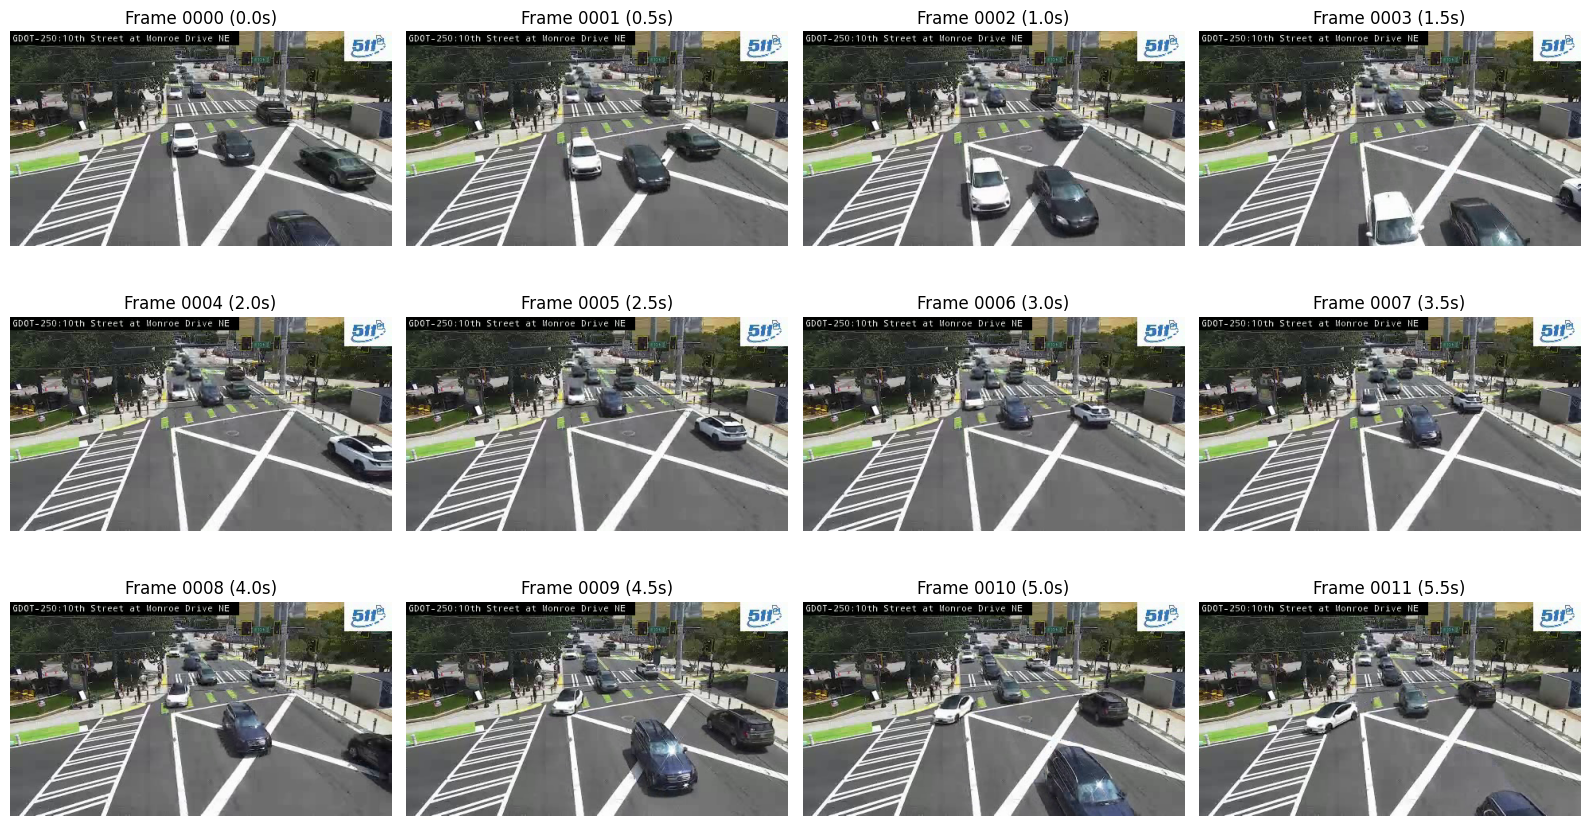


✓ Extracted: 129 frames
✓ Saved to: data/frames/ATL-0610_20250623_004147
  Frame size: (270, 480, 3)


In [17]:
import cv2
from pathlib import Path
import matplotlib.pyplot as plt

# setup paths
frames_dir = Path(params['output_frames_dir']) / f"{params['camera_id']}_{timestamp}"
frames_dir.mkdir(parents=True, exist_ok=True)

# load clip
cap = cv2.VideoCapture(str(clip_path))
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# calc intervals
interval_frames = int(fps * params['frame_interval'])
total_extracts = int(params['clip_duration'] / params['frame_interval'])

# extract
extracted = 0
preview_frames = []
for i in range(0, frame_count, interval_frames):
    cap.set(cv2.CAP_PROP_POS_FRAMES, i)
    ret, frame = cap.read()
    if not ret:
        break
    
    # save frame
    frame_name = f"{params['frame_prefix']}{extracted:04d}{params['frame_format']}"
    frame_path = frames_dir / frame_name
    cv2.imwrite(str(frame_path), frame, [cv2.IMWRITE_JPEG_QUALITY, params['frame_quality']])
    
    # store for preview
    if extracted < 12:  # first 12 frames
        preview_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    
    extracted += 1
    if extracted % 20 == 0:
        print(f"Extracted: {extracted} frames")

cap.release()

# preview
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for idx, ax in enumerate(axes.flat):
    if idx < len(preview_frames):
        ax.imshow(preview_frames[idx])
        ax.set_title(f"Frame {idx:04d} ({idx*params['frame_interval']:.1f}s)")
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\n✓ Extracted: {extracted} frames")
print(f"✓ Saved to: {frames_dir}")
print(f"  Frame size: {frame.shape}")

## Apply Preprocessing to Frames

This cell applies preprocessing to all extracted frames. The preprocessing:
- Loads each frame from disk
- Applies Gaussian blur for noise reduction
- Overwrites original frames with processed versions
- Displays before/after comparison

Found 129 frames


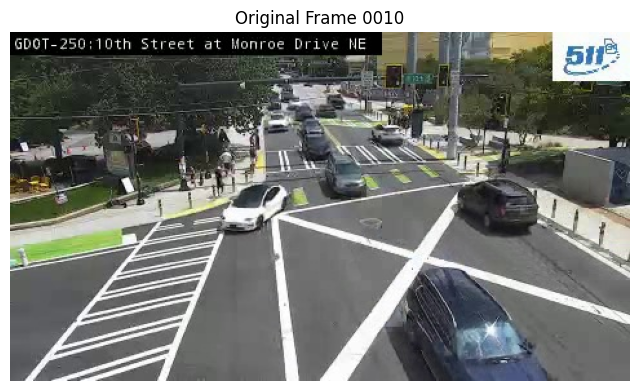

✓ Frames ready for enhancement
  Frame shape: (270, 480, 3)


In [18]:
import cv2
import numpy as np
from pathlib import Path

# get frames
frame_files = sorted(frames_dir.glob(f"*{params['frame_format']}"))
print(f"Found {len(frame_files)} frames")

# load sample for baseline
sample_idx = 10  # middle frame
original_frame = cv2.imread(str(frame_files[sample_idx]))
original_rgb = cv2.cvtColor(original_frame, cv2.COLOR_BGR2RGB)

# show original
plt.figure(figsize=(8, 6))
plt.imshow(original_rgb)
plt.title(f"Original Frame {sample_idx:04d}")
plt.axis('off')
plt.show()

print(f"✓ Frames ready for enhancement")
print(f"  Frame shape: {original_frame.shape}")

## Background Subtraction for Motion Detection

This cell applies background subtraction to isolate moving vehicles. The process:
- Uses MOG2 background subtractor
- Learns static background over multiple frames
- Highlights only moving objects
- Creates binary masks for vehicle detection

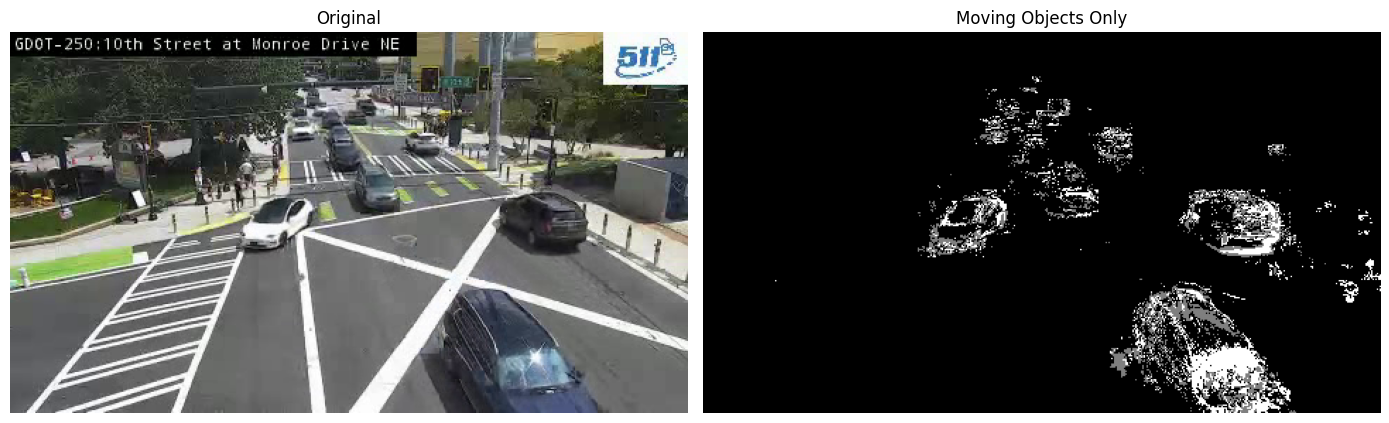

White pixels = moving vehicles
Black = static background
Gray = shadows


In [19]:
# create bg subtractor
backSub = cv2.createBackgroundSubtractorMOG2(detectShadows=True)

# process frames
cap = cv2.VideoCapture(str(clip_path))
cap.set(cv2.CAP_PROP_POS_FRAMES, sample_idx * int(fps * params['frame_interval']))
ret, frame = cap.read()

# learn bg
for i in range(30):  # learn from 30 frames
    ret, temp = cap.read()
    if ret:
        backSub.apply(temp)

# apply to sample
fgMask = backSub.apply(frame)

# display
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax1.set_title("Original")
ax1.axis('off')

ax2.imshow(fgMask, cmap='gray')
ax2.set_title("Moving Objects Only")
ax2.axis('off')

plt.tight_layout()
plt.show()

cap.release()

print("White pixels = moving vehicles")
print("Black = static background")
print("Gray = shadows")

## Frame Differencing

This cell highlights movement by showing differences between consecutive frames. The process:
- Compares two consecutive frames
- Shows only pixels that changed
- Creates a difference map highlighting motion
- Simple and effective for motion detection

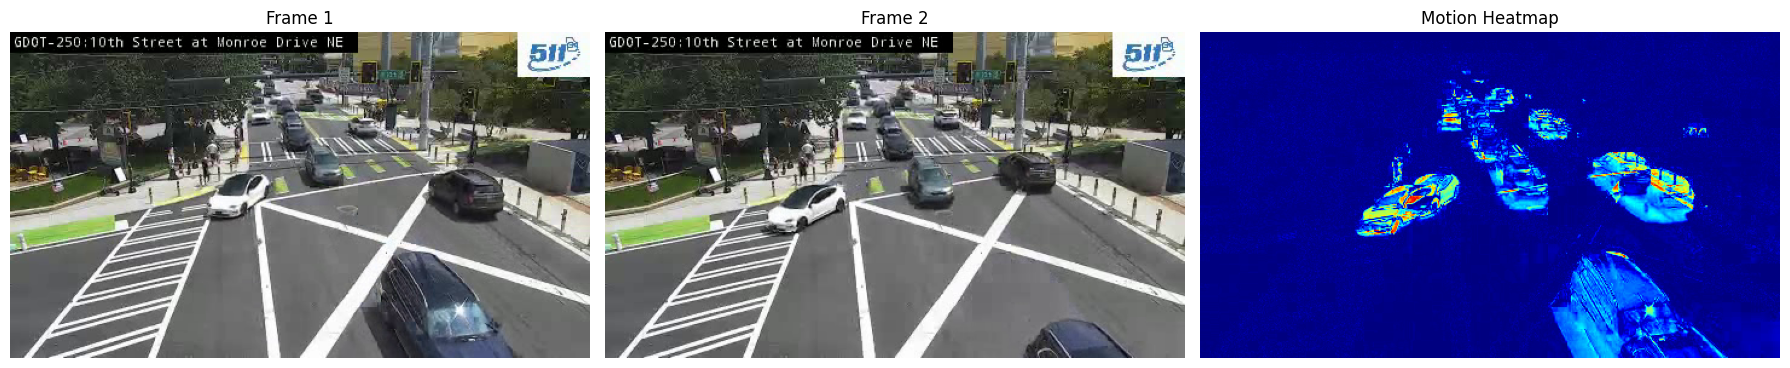

Red/yellow = high motion
Blue/black = no motion


In [20]:
# get consecutive frames
cap = cv2.VideoCapture(str(clip_path))
cap.set(cv2.CAP_PROP_POS_FRAMES, sample_idx * int(fps * params['frame_interval']))
ret, frame1 = cap.read()

# next frame
cap.set(cv2.CAP_PROP_POS_FRAMES, (sample_idx + 1) * int(fps * params['frame_interval']))
ret, frame2 = cap.read()

# calc difference
diff = cv2.absdiff(frame1, frame2)
gray_diff = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

# threshold
_, thresh = cv2.threshold(gray_diff, 30, 255, cv2.THRESH_BINARY)

# colorize
heatmap = cv2.applyColorMap(gray_diff, cv2.COLORMAP_JET)

# display
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
axes[0].set_title("Frame 1")
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))
axes[1].set_title("Frame 2")
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
axes[2].set_title("Motion Heatmap")
axes[2].axis('off')

plt.tight_layout()
plt.show()

cap.release()

print("Red/yellow = high motion")
print("Blue/black = no motion")


## CLAHE (Adaptive Histogram Equalization)

This cell applies Contrast Limited Adaptive Histogram Equalization. The process:
- Divides image into small tiles
- Equalizes each tile independently
- Limits contrast to avoid amplifying noise
- Better than global histogram equalization for varying lighting

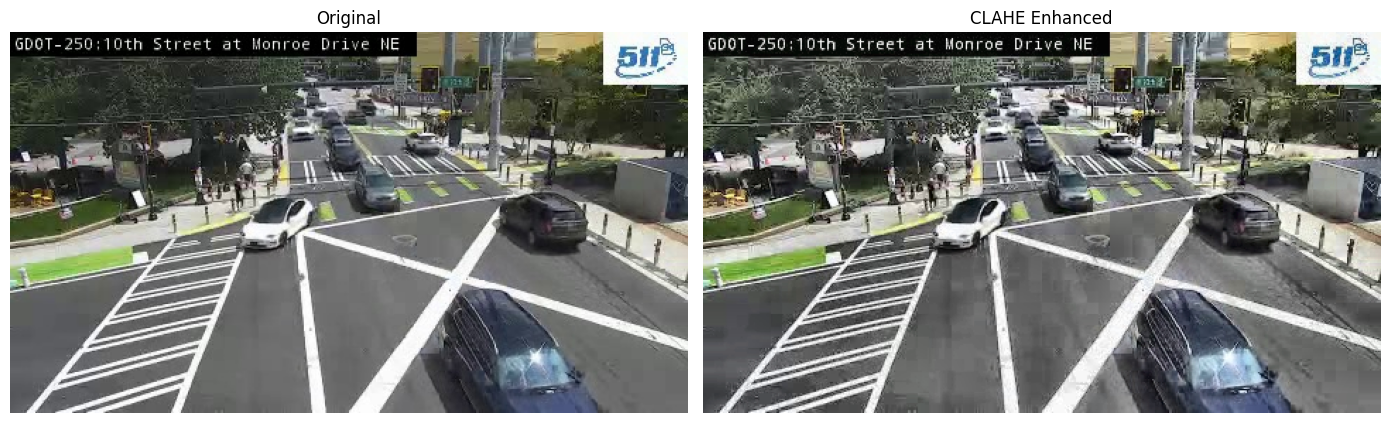

Enhances local contrast
Preserves natural colors
Good for varying lighting conditions


In [21]:
# create clahe
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

# apply to sample
lab = cv2.cvtColor(original_frame, cv2.COLOR_BGR2LAB)
lab[:,:,0] = clahe.apply(lab[:,:,0])
enhanced_clahe = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

# compare
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.imshow(original_rgb)
ax1.set_title("Original")
ax1.axis('off')

ax2.imshow(cv2.cvtColor(enhanced_clahe, cv2.COLOR_BGR2RGB))
ax2.set_title("CLAHE Enhanced")
ax2.axis('off')

plt.tight_layout()
plt.show()

print("Enhances local contrast")
print("Preserves natural colors")
print("Good for varying lighting conditions")

## Apply Selected Preprocessing to All Frames

This cell applies the chosen preprocessing technique to all extracted frames. Options:
- 'none' - keep original frames
- 'clahe' - enhance contrast
- 'diff' - frame differencing (requires pairs)
- 'mog2' - background subtraction

In [22]:
# select method
preprocessing_method = params['preprocessing_method']

if preprocessing_method == 'clahe':
    # setup clahe
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    
    # process all
    for frame_path in frame_files:
        img = cv2.imread(str(frame_path))
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        lab[:,:,0] = clahe.apply(lab[:,:,0])
        enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
        cv2.imwrite(str(frame_path), enhanced, [cv2.IMWRITE_JPEG_QUALITY, params['frame_quality']])
    
    print(f"Applied CLAHE to {len(frame_files)} frames")

elif preprocessing_method == 'mog2':
    # bg subtractor
    backSub = cv2.createBackgroundSubtractorMOG2(detectShadows=True)
    cap = cv2.VideoCapture(str(clip_path))
    
    # learn background
    for i in range(30):
        ret, frame = cap.read()
        if ret:
            backSub.apply(frame)
    
    # process frames
    for idx, frame_path in enumerate(frame_files):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx * int(fps * params['frame_interval']))
        ret, frame = cap.read()
        if ret:
            fgMask = backSub.apply(frame)
            # convert to 3 channel
            mask_3ch = cv2.cvtColor(fgMask, cv2.COLOR_GRAY2BGR)
            cv2.imwrite(str(frame_path), mask_3ch, [cv2.IMWRITE_JPEG_QUALITY, params['frame_quality']])
    
    cap.release()
    print(f"Applied MOG2 to {len(frame_files)} frames")

elif preprocessing_method == 'diff':
    # frame diff
    cap = cv2.VideoCapture(str(clip_path))
    
    for idx in range(len(frame_files) - 1):
        # get consecutive frames
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx * int(fps * params['frame_interval']))
        ret1, frame1 = cap.read()
        cap.set(cv2.CAP_PROP_POS_FRAMES, (idx + 1) * int(fps * params['frame_interval']))
        ret2, frame2 = cap.read()
        
        if ret1 and ret2:
            diff = cv2.absdiff(frame1, frame2)
            gray_diff = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
            heatmap = cv2.applyColorMap(gray_diff, cv2.COLORMAP_JET)
            cv2.imwrite(str(frame_files[idx]), heatmap, [cv2.IMWRITE_JPEG_QUALITY, params['frame_quality']])
    
    # copy last frame
    cv2.imwrite(str(frame_files[-1]), heatmap, [cv2.IMWRITE_JPEG_QUALITY, params['frame_quality']])
    
    cap.release()
    print(f"Applied frame differencing to {len(frame_files)} frames")

elif preprocessing_method == 'none':
    print("Keeping original frames")

else:
    print(f"Unknown method: {preprocessing_method}")

Applied frame differencing to 129 frames


## Save Configuration for Next Steps

This cell exports preprocessing parameters and file paths to JSON. The output:
- Records all processing parameters used
- Saves input/output paths for downstream notebooks
- Includes frame count and metadata
- Creates config file for annotation workflow

In [23]:
import json
from datetime import datetime

# gather config
config = {
    'camera_id': params['camera_id'],
    'processing_timestamp': timestamp,
    'clip_path': str(clip_path),
    'frames_dir': str(frames_dir),
    'frame_count': len(frame_files),
    'frame_paths': [str(f) for f in frame_files],
    'preprocessing_method': params['preprocessing_method'],
    'frame_interval': params['frame_interval'],
    'clip_duration': params['clip_duration'],
    'video_properties': {
        'width': width,
        'height': height,
        'fps': fps
    }
}

# save json
config_path = Path('configs') / f"preprocessing_{timestamp}.json"
config_path.parent.mkdir(exist_ok=True)

with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f"✓ Saved config: {config_path}")
print(f"  Frames: {config['frame_count']}")
print(f"  Method: {config['preprocessing_method']}")

✓ Saved config: configs/preprocessing_20250623_004147.json
  Frames: 129
  Method: diff
